In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

df = pd.read_csv('../data/telco_churn.csv')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
from pandas import errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Quantas linhas estao nulas
print(df['TotalCharges'].isnull().sum())

#Sao clientes com ternure = 0 - Recem chegados, sem cobrança ainda
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges', 'TotalCharges']]

11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


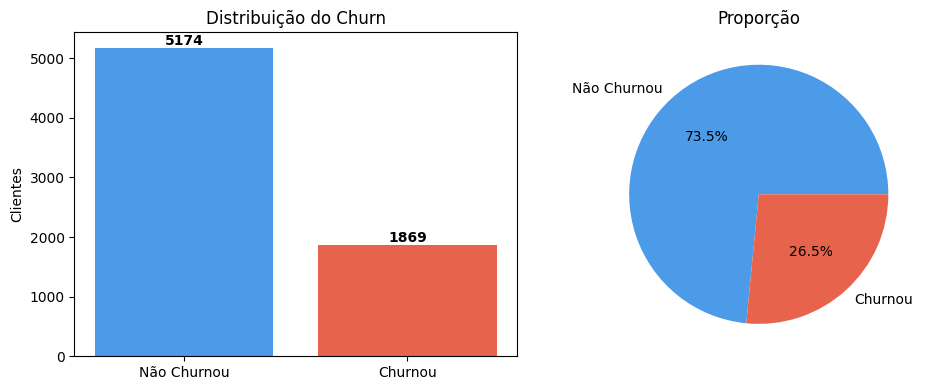

Taxa de Churn: 26.5%


In [14]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize = True)*100
fig, axes = plt.subplots(1,2,figsize=(10,4))

#contagem absoluta

axes[0].bar(['Não Churnou','Churnou'], churn_counts.values,
color=['#4C9BE8', '#E8634C'])

axes[0].set_title('Distribuição do Churn')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct.values, labels=['Não Churnou', 'Churnou'],autopct='%1.1f%%',colors=['#4C9BE8', '#E8634C'])

axes[1].set_title('Proporção')

plt.tight_layout()
plt.savefig('../assets/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Taxa de Churn: {churn_pct['Yes']:.1f}%")

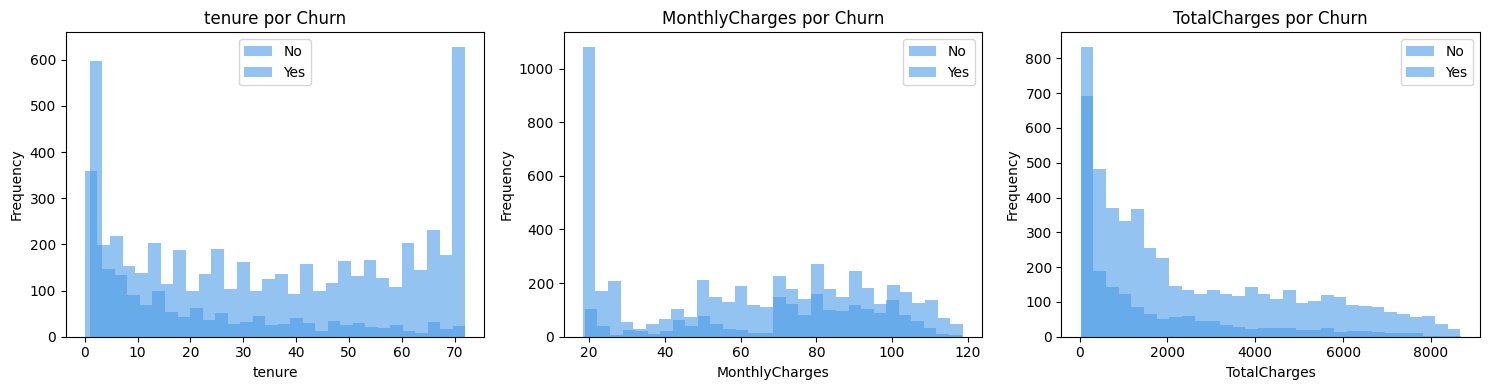

In [15]:
num_features = ['tenure','MonthlyCharges','TotalCharges']

fig, axes = plt.subplots(1,3,figsize=(15,4))

for i, feat in enumerate(num_features):
    df.groupby('Churn')[feat].plot(
        kind='hist',alpha=0.6,bins=30,ax=axes[i],
        color=['#4C9BE8', '#E8634C'], legend=True
    )

    axes[i].set_title(f'{feat} por Churn')
    axes[i].set_xlabel(feat)

plt.tight_layout()
plt.savefig('../assets/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

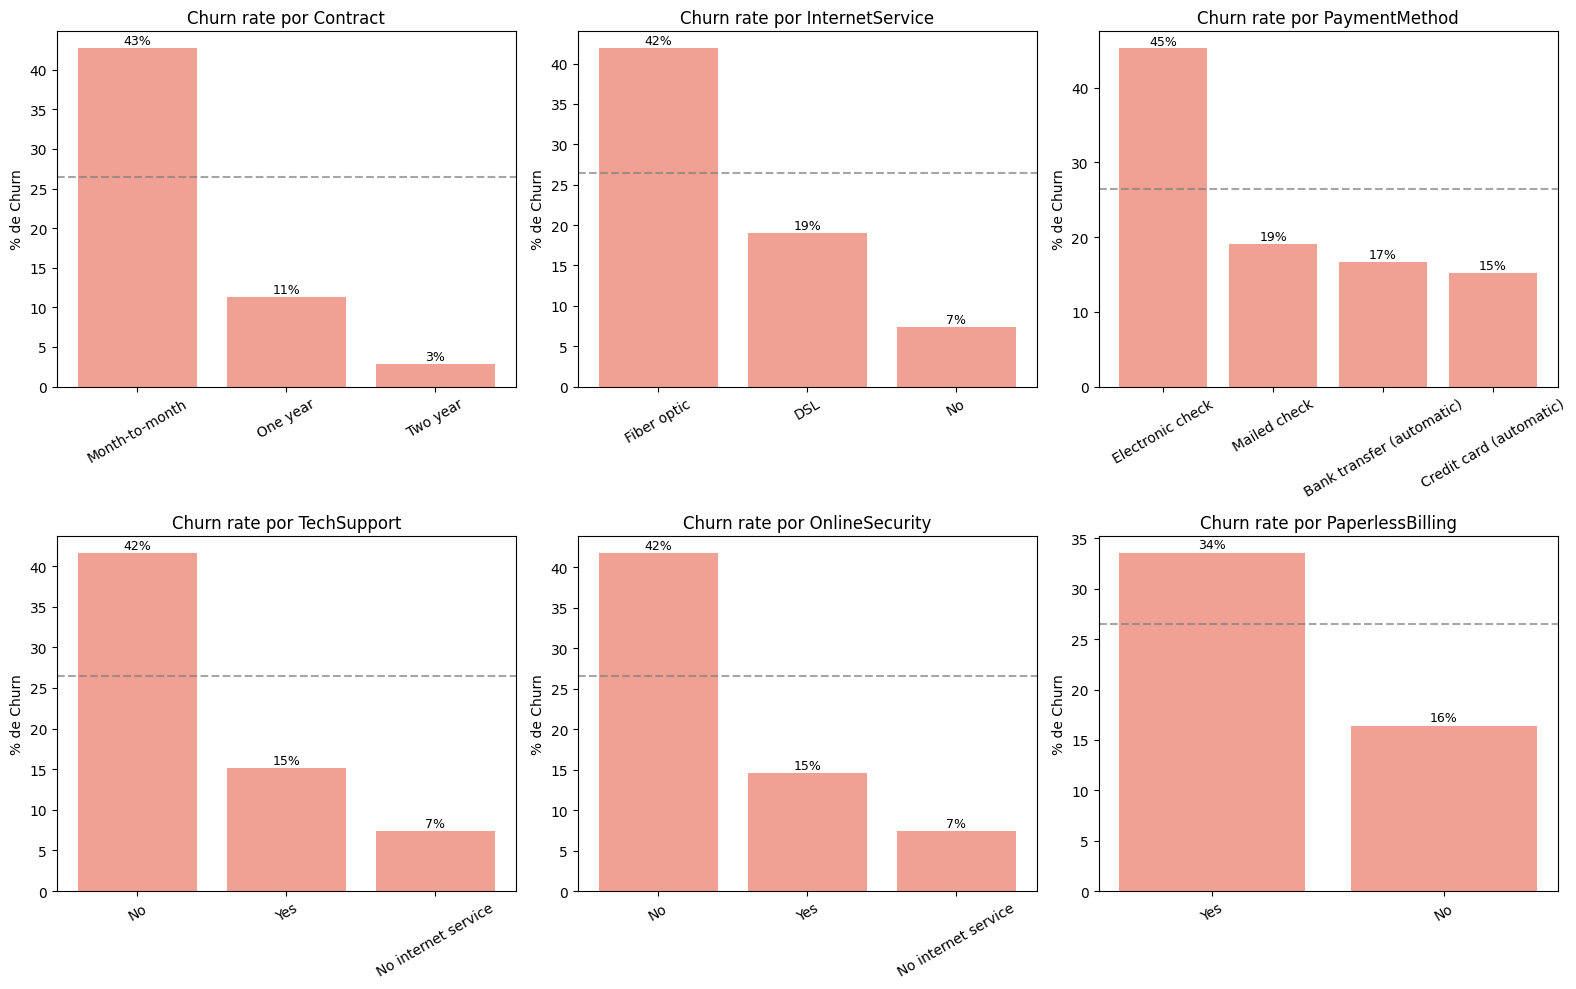

In [19]:
cat_features = ['Contract','InternetService','PaymentMethod','TechSupport'
                ,'OnlineSecurity','PaperlessBilling']

fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    churn_rate = df.groupby(feat)['Churn'].apply(
        lambda x:(x=='Yes').mean()*100
    ).sort_values(ascending=False)

    bars = axes[i].bar(churn_rate.index, churn_rate.values, color='#E8634C',alpha=0.6)
    axes[i].set_title(f'Churn rate por {feat}')
    axes[i].set_ylabel('%'+' de Churn')
    axes[i].tick_params(axis='x',rotation=30)
    axes[i].axhline(y=26.5, color='grey',linestyle='--',alpha=0.7,label='Média geral')

    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
        f'{val:.0f}%',ha='center',fontsize=9)

plt.tight_layout()
plt.savefig('../assets/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

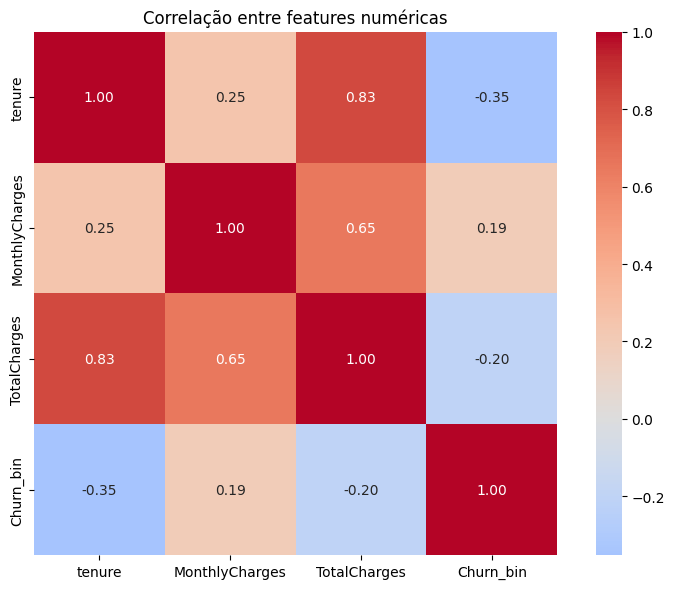

In [22]:
fig, ax = plt.subplots(figsize=(8,6))


df_corr = df.copy()
df_corr['Churn_bin']=(df_corr['Churn']=='Yes').astype(int)

corr_matrix = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']].corr()

sb.heatmap(corr_matrix,annot=True, fmt='.2f',cmap='coolwarm',center=0,ax=ax,square=True)

ax.set_title('Correlação entre features numéricas')

plt.tight_layout()
plt.savefig('../assets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusões do EDA

**Perfil do cliente que churna:**
- Contrato mensal (43% de churn vs 3% no bienal)
- Serviço de Fiber Optic (42% de churn)
- Sem suporte técnico e sem segurança online
- Tenure baixo — maioria nos primeiros 12 meses
- Paga mais por mês que clientes que ficam

**Implicações para o modelo:**
- Dataset desbalanceado (26.5% churn) → usar scale_pos_weight no XGBoost
- TotalCharges e tenure são colineares → monitorar importância de features
- Contract é provavelmente a feature mais importante → confirmar com SHAP